# Forcasting Harmonic Osscilators using a Physics Informed Neural Network in Pytorch


**Loading in librarys**

In [8]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from Oscillators import *


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Generating training and testing data



In [9]:
m = 1.0
k = 1.0
A_0 = 1.0
v_0 = 0.0
b = 0.01
F_0 = 1
w_0 = 0.8


oscillator = Harmonic_Oscillator(
    mass=m,
    force_const=k,          # → ω₀ = √(k/m) = 1.0
    initial_amplitude=A_0,    # Start with same amplitude as driven oscillation
    velocity=v_0,             # Zero initial velocity for clean phase
    damping_const=b,       # Very light damping (γ = b/2m = 0.005)
    driving_force=F_0,
    driving_frequency=w_0    # Close to ω₀ = 1.0 → beat frequency ≈ 0.05
)

points = 1000
t = np.linspace(0, 100, 1000)
x = oscillator.get_x_pos(t)

# normalising values around zero so work better in neural network
t_mean, t_std = float(t.mean()), float(t.std())
t_norm = (t-t_mean) / t_std

x_mean, x_std = float(x.mean()), float(x.std())
x_norm = (x-x_mean) / x_std




# two regimes: dense and forcast, dense just goes over all points and radomly selects `training values` numbers of points
# forcast splits it into a percentage so the data can be forcasted

regime = "dense"
forecast_split = 50.0

training_values = 100

np.random.seed(42)

if regime == "forecast":
    label_pool = np.where(t <= forecast_split)[0]
    forecast_index = np.where(t > forecast_split)[0]     # returns when elemnet is true in index one, and false in index 2
else:
    label_pool = np.arange(points)
    forecast_index = np.array([], dtype=int)

# without replacement and over the full pool - randint(0, points - 1) both
# duplicated indices and could never pick the final point
training_index = np.random.choice(label_pool, training_values, replace=False)

# unlabelled points inside the labelled window: interpolation error
interp_index = np.setdiff1d(label_pool, training_index)

print(f"regime={regime}  labels={len(training_index)} drawn from t<={t[label_pool].max():.1f}"
      f"  | interp points={len(interp_index)}  forecast points={len(forecast_index)}")


def gather(idx):
    return [t_norm[i] for i in idx], [x_norm[i] for i in idx]

training_data_t, training_data_x = gather(training_index)
interp_data_t,   interp_data_x   = gather(interp_index)
forecast_data_t, forecast_data_x = gather(forecast_index)


regime=dense  labels=100 drawn from t<=100.0  | interp points=900  forecast points=0


In [10]:
batch_size = 100


def as_tensor(vals):
    return torch.tensor(vals, dtype=torch.float32).reshape(-1, 1)


# Turned into a tensor to create data to be used in nn
training_data_t, training_data_x = as_tensor(training_data_t), as_tensor(training_data_x)
interp_data_t,   interp_data_x   = as_tensor(interp_data_t),   as_tensor(interp_data_x)
forecast_data_t, forecast_data_x = as_tensor(forecast_data_t), as_tensor(forecast_data_x)


training_dataset = TensorDataset(training_data_t, training_data_x)
interp_dataset   = TensorDataset(interp_data_t,   interp_data_x)
forecast_dataset = TensorDataset(forecast_data_t, forecast_data_x)

training_dataloader = DataLoader(training_dataset, shuffle=True, batch_size=batch_size)

# full-batch and unshuffled, so predictions as forcasting needs time order
# could maybe do windows if going for a longer dataset? 
# going to just incrementlay increase amound nn can view 
interp_dataloader = DataLoader(interp_dataset, batch_size=max(len(interp_dataset), 1))

forecast_dataloader = (DataLoader(forecast_dataset, batch_size=len(forecast_dataset))
                       if len(forecast_dataset) else None)

for X, y in training_dataloader:
    print(f"Shape of X: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break


Shape of X: torch.Size([100, 1])
Shape of y: torch.Size([100, 1]) torch.float32


## Defining a model 

In [11]:
# Define model
hidden_neurons = 64

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear_tanh_stack = nn.Sequential(
            
            nn.Linear(1, hidden_neurons),
            nn.Tanh(),
            nn.Linear(hidden_neurons, hidden_neurons),
            nn.Tanh(),
            nn.Linear(hidden_neurons, 1)
        )

    def forward(self, t):

        logits = self.linear_tanh_stack(t)
        return logits



### Loss function


In [12]:

n_colloc = 2000 # number of poinst nn will be trained on through out the entire data set (remember x does not need to be known)
physics_const = 1 # represents proportion of the loss function being trained by physics const
basic_const = 0 # proportion trained be basic nn MSE(pred, expected)


def ode_residual(t_colloc, x_colloc):
    """Dimensionless residual of  m * d2x/dt2 + b * dx/dt + k * x - F_0 cos(w_0 t),
    given the network's normalised output x_colloc = x_norm(t_norm).
    """
    dxdt_norm = torch.autograd.grad(x_colloc, t_colloc, 
                               grad_outputs=torch.ones_like(x_colloc), # means doenst calculate arbritaty calculations between x_i and t_j thoughout nn (saves time)
                               create_graph=True)[0]

    d2xdt2_norm = torch.autograd.grad(dxdt_norm, t_colloc, 
                               grad_outputs=torch.ones_like(dxdt_norm),
                               create_graph=True)[0]

    # the network outputs x_norm as a function of t_norm, so undo BOTH
    # normalisations before the derivatives mean anything physically:
    #   x = x_norm * x_std + x_mean,  t = t_norm * t_std + t_mean
    # dx/dt    = dx_norm/dt_norm * x_std / t_std
    # d2x/dt2  = d2x_norm/dt_norm2 * x_std / t_std ** 2
    dxdt = dxdt_norm * x_std / t_std
    d2xdt2 = d2xdt2_norm * x_std / t_std ** 2

    x_phys = x_colloc * x_std + x_mean
    t_phys = t_colloc * t_std + t_mean

    # divided by F_0 so the residual is dimensionless and physics_const is O(1)
    return (m * d2xdt2 + b * dxdt + k * x_phys - F_0 * torch.cos(w_0 * t_phys)) / F_0


class CustomLoss(nn.Module):
    def __init__(self):
        super(CustomLoss, self).__init__()

    def forward(self, output, target, t_colloc, x_colloc):

        basic_loss = nn.functional.mse_loss(output, target)

        # also need it to fit to osccilator equation
        # can use any arbritary t, as we are not labling them with correct solution
        residual = ode_residual(t_colloc, x_colloc)
        colloc_loss = nn.functional.mse_loss(residual, torch.zeros_like(residual))

        return basic_const * basic_loss + physics_const * colloc_loss





## Training

In [13]:
t_lo, t_hi = float(t_norm.min()), float(t_norm.max())


def make_colloc(n, s_hi=None):
    """Creates tensor to device used, that  are random numbers between [0, 1),
        multiplied by the range to give the apropiate number of random colloction points"""
    hi = t_hi if s_hi is None else s_hi
    return (torch.rand(n, 1, device=device) * (hi - t_lo) + t_lo).requires_grad_(True)


def run_training(use_physics, epochs=8000, lr=1e-3, use_scheduler=True,
                 seed=0, log_every=500, curriculum=None):
    """Train a fresh network and return it.
    use_physics: bool, represents if PINN should be used
    curriculum: list, represents increasing size of periods model will be 
        trained over to help with forcasting (not normalised)
    """
    torch.manual_seed(seed)                 # identical init for both runs, so any
    model = NeuralNetwork().to(device) # same model used throughout training     # difference is down to the physics term
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = CustomLoss() if use_physics else nn.MSELoss()

    if curriculum is None:
        curriculum = [float(t.max())]
    stages = [(T - t_mean) / t_std for T in curriculum]   # -> normalised time
    epochs_per_stage = epochs // len(stages)

    history = []
    for stage, s_hi in enumerate(stages):
        # learning rates need to be reset on each stages or CosineAnnealingLR make effects of later stages negligable
        for group in optimizer.param_groups:
            group["lr"] = lr
        scheduler = (torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=epochs_per_stage) if use_scheduler else None)
        if len(stages) > 1:
            print(f"-- stage {stage+1}/{len(stages)}: t <= {curriculum[stage]:.1f}")

        for epoch in range(epochs_per_stage):
            model.train()
            for T, X in training_dataloader:
                T, X = T.to(device), X.to(device)

                # the data term is restricted to the current stage too, so early
                # stages aren't pulled by labels beyond where physics is enforced
                mask = (T <= s_hi).squeeze(-1)
                if mask.any():
                    data_pred, data_target = model(T[mask]), X[mask]
                else:
                    data_pred = data_target = None

                if use_physics:
                    t_colloc = make_colloc(n_colloc, s_hi)
                    x_colloc = model(t_colloc)
                    if data_pred is None:      # no labels yet in this window
                        residual = ode_residual(t_colloc, x_colloc)
                        loss = physics_const * nn.functional.mse_loss(
                            residual, torch.zeros_like(residual))
                    else:
                        loss = loss_fn(data_pred, data_target, t_colloc, x_colloc)
                else:
                    if data_pred is None:
                        continue               # nothing to learn from yet
                    loss = loss_fn(data_pred, data_target)

                # Backpropagation
                loss.backward()
                optimizer.step()
                optimizer.zero_grad()

            if scheduler is not None:
                scheduler.step()

            history.append(loss.item())
            if epoch % log_every == 0 or epoch == epochs_per_stage - 1:
                print(f"epoch {epoch+1:>6}/{epochs_per_stage}  loss {loss.item():.6f}"
                      f"  lr {optimizer.param_groups[0]['lr']:.2e}")

    return model, history


def evaluate(model, dataloader, label=""):
    """Data MSE and physics residual reported SEPARATELY, so the basic and PINN
    runs are measured on the same scale whichever loss trained them. The combined
    training objective is not comparable between the two."""
    if dataloader is None:
        print(f"{label}  (no points in this region for regime={regime})")
        return None

    model.eval()

    sq, n = 0.0, 0
    with torch.no_grad():                   # the data term needs no graph...
        for T, X in dataloader:
            T, X = T.to(device), X.to(device)
            sq += nn.functional.mse_loss(model(T), X, reduction="sum").item()
            n += X.numel()
    data_mse = sq / n

    t_colloc = make_colloc(n_colloc)        # ...but the residual does
    physics_mse = ode_residual(t_colloc, model(t_colloc)).pow(2).mean().item()

    print(f"{label}  data MSE {data_mse:.6f}"
          f"  | RMSE {np.sqrt(data_mse) * x_std:.4f} (units of x)"
          f"  | physics residual MSE {physics_mse:.6f}")
    return {"data_mse": data_mse, "physics_mse": physics_mse}


### Training the basic network

Data only — plain MSE against the labelled points. Nothing constrains what the network
does between them, and in the `forecast` regime nothing whatsoever constrains it past
`forecast_split`.

**Control case, already measured.** With `regime = "dense"` the basic network *wins*,
and that is the correct result rather than a bug: 100 labels over 16 oscillation periods
is 6.3 labels per period, so the labels already determine the curve everywhere. The ODE
residual adds no information the labels don't carry, while making the objective far
harder to optimise (it depends on the network's second derivative) and ~3× slower per
step. A PINN cannot win an interpolation problem. Set `regime = "dense"` in the data
cell to reproduce it.

Physics only pays off where data is *absent* — which is what the `forecast` regime below
sets up.

In [14]:
model_basic, hist_basic = run_training(use_physics=False, epochs=1, lr=1e-3)

res_basic_i = evaluate(model_basic, interp_dataloader,   label="basic interp  ")
res_basic_f = evaluate(model_basic, forecast_dataloader, label="basic forecast")


epoch      1/1  loss 1.099510  lr 0.00e+00
basic interp    data MSE 1.017056  | RMSE 2.0794 (units of x)  | physics residual MSE 0.623487
basic forecast  (no points in this region for regime=dense)


### Training the PINN

Same data loss plus the ODE residual evaluated at `n_colloc` unlabelled collocation
points spanning the **whole** domain — including past `forecast_split`, where there are
no labels at all. That residual is the only thing supplying information about the
future, and it is the entire mechanism by which the PINN can forecast.

The curriculum grows the domain in stages (≈2, 4, 8, then all 16 periods). Without it a
vanilla PINN drifts out of phase across a domain this long, because the residual is a
*local* constraint and phase information doesn't propagate across many cycles.

In [15]:
model_pinn, hist_pinn = run_training(use_physics=True, epochs=40000, lr=1e-3,
                                     )

res_pinn_i = evaluate(model_pinn, interp_dataloader,   label="PINN  interp  ")
res_pinn_f = evaluate(model_pinn, forecast_dataloader, label="PINN  forecast")


epoch      1/40000  loss 0.733812  lr 1.00e-03
epoch    501/40000  loss 0.499424  lr 1.00e-03
epoch   1001/40000  loss 0.505532  lr 9.98e-04
epoch   1501/40000  loss 0.501458  lr 9.97e-04
epoch   2001/40000  loss 0.489202  lr 9.94e-04
epoch   2501/40000  loss 0.497706  lr 9.90e-04
epoch   3001/40000  loss 0.490095  lr 9.86e-04
epoch   3501/40000  loss 0.496848  lr 9.81e-04
epoch   4001/40000  loss 0.487030  lr 9.76e-04
epoch   4501/40000  loss 0.495976  lr 9.69e-04
epoch   5001/40000  loss 0.496411  lr 9.62e-04
epoch   5501/40000  loss 0.475640  lr 9.54e-04
epoch   6001/40000  loss 0.481364  lr 9.45e-04
epoch   6501/40000  loss 0.489813  lr 9.36e-04
epoch   7001/40000  loss 0.472702  lr 9.26e-04
epoch   7501/40000  loss 0.469291  lr 9.16e-04
epoch   8001/40000  loss 0.460716  lr 9.04e-04
epoch   8501/40000  loss 0.456044  lr 8.93e-04
epoch   9001/40000  loss 0.450288  lr 8.80e-04
epoch   9501/40000  loss 0.433969  lr 8.67e-04
epoch  10001/40000  loss 0.450542  lr 8.54e-04
epoch  10501/

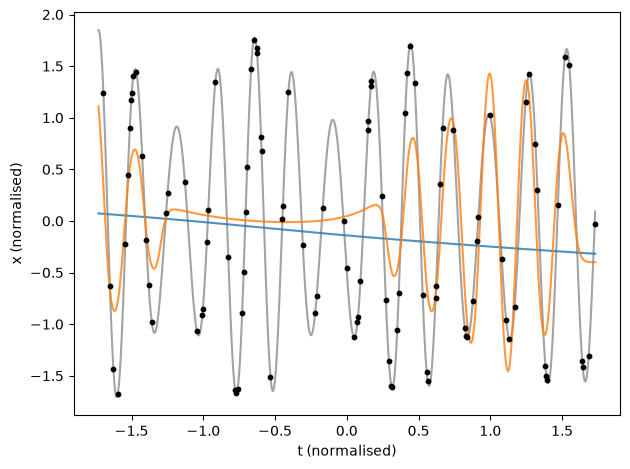

In [16]:
### Plotting Results
t_grid = torch.tensor(t_norm, dtype=torch.float32).reshape(-1, 1).to(device)

# whichever training cells have been run
trained = {}
if "model_basic" in globals():
    trained["basic"] = (model_basic, hist_basic)
if "model_pinn" in globals():
    trained["PINN"] = (model_pinn, hist_pinn)

fig, ax = plt.subplots()

ax.plot(t_norm, x_norm, label="actual", color="0.4", alpha=0.6)
for name, (mdl, _) in trained.items():
    mdl.eval()
    with torch.no_grad():
        pred = mdl(t_grid).cpu().squeeze()
    ax.plot(t_norm, pred, label=f"{name} prediction", alpha=0.8)

# the training points - gaps between them are where the fit is free to wander
ax.scatter(t_norm[training_index], x_norm[training_index],
           s=10, color="k", zorder=3, label="training points")


if len(forecast_index):
    s_split = (forecast_split - t_mean) / t_std
    ax.axvline(s_split, color="crimson", lw=1.2, ls="--")
    ax.axvspan(s_split, t_hi, color="crimson", alpha=0.07,
               label="forecast region (no labels)")

ax.set_xlabel("t (normalised)")
ax.set_ylabel("x (normalised)")
#ax.legend(loc="upper left", fontsize=8)


fig.tight_layout()
plt.savefig(f"no_training_points_2000_coloc_64_neurons_40000_epochs.pdf")
